# Consensus vs LLM judges on fresh logic data (E2-A)

**Question.** Given a natural-language sentence and a candidate first-order-logic (FOL) formalization, and **no gold formula**,
can a cheap score predict whether the formalization is *faithful* to the text?

This artifact is the pre-registered confirmation test of the frozen **cross-family solver consensus** score
`c_score_align` (**V0**) on an untouched NL→FOL set (E2). V0 compares a candidate with the formalizations of the *same* sentence
written by other model families. It is `1 - (share of peers that z3 proves equivalent to the candidate, modulo a
predicate/constant vocabulary alignment)`. V0 is compared with:

* **text-side checks**: L2-bow (sentence words the formula's symbols do not carry) and L3 (role questionnaire vs z3 role profile);
* **LLM judges**: a local Qwen3-8B rubric judge (the declared substitute bar after the API budget ran out). The API judges are mostly missing;
* **the user's pilot structural metrics**: joint-load conflict, arity/shape inconsistency, dangling symbols, and 1 - rerun Jaccard;
* **consensus variants** V1-V5, `c_exact` (no aligner), and the frozen fusion **PT** `p_peer_text`.

Every score is oriented **higher = more likely ERROR**. Labels (CORRECT / ERROR) come from a multi-family panel
(tiers A/B) or, in the DT stratum, from prover-built gold, and were **sealed before** the scores were joined.

**What this notebook runs.** `method.py` is a stage orchestrator: it launches the scoring scripts (z3 consensus, API judges,
a GPU judge), the label pipeline, and then the analysis. The paid and GPU stages can't be re-run in Colab. Their outputs
(sealed scores + labels) are shipped in `mini_demo_data.json` as a 98-row / 13-sentence subset of the 273 analysed rows.
The notebook shows the orchestration map verbatim, then runs the **analysis stage code** (copied from `analysis/analyse_E2A.py`,
the frozen `stats.py`, and the independent `audit/rederive.py`): stratified AUROC, sentence-cluster bootstrap CIs, paired
deltas, complexity bins, system-level Kendall τ and a shuffled-label placebo.

**Full-run headline** (273 rows): V0 strat-AUROC 0.890 vs local 8B judge 0.895 (Δ −0.005, CI includes 0). On DT, V0 0.916.
The pilot structural metrics sit at about 0.5 (they do not track correctness). V0 is **not** rename-invariant: 100% of
nonce-renamed correct formulas are flagged.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, scipy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
# --- original method.py imports ---
from __future__ import annotations

import argparse
import os
import subprocess
import sys
from pathlib import Path

# --- imports of the analysis stage (analysis/analyse_E2A.py, frozen stats.py, audit/rederive.py) ---
import json
import math
import random
from collections import Counter, defaultdict

import numpy as np
from scipy.stats import rankdata, kendalltau
from sklearn.metrics import roc_auc_score

# --- notebook-only: visualization ---
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_StxQVNnY7aQW/round-5/experiment-11/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("rows:", data["metadata"]["n_examples"], "| sentences:", data["metadata"]["n_sentences"])
print("stratum:label counts:", data["metadata"]["by_stratum_label"])
ex0 = data["examples"][0]
print("\nexample row:\n  text:", ex0["text"], "\n  candidate FOL:", ex0["candidate_fol"],
      "\n  label:", ex0["label"], ex0["error_ops"], "| V0 =", ex0["c_score_align"], "| local judge =", round(ex0["judge_local_qwen8b_disg"], 3))

E2-A mini demo: 98 labelled NL->FOL candidates (whole sentences, R_AB regime: label CORRECT/ERROR, tier A/B, no reading choice) from the analysed 110-sentence prefix, with every sealed label-free score. All score columns are oriented HIGHER = MORE LIKELY ERROR; null = not computed (e.g. API judges after the budget stop).
rows: 98 | sentences: 13
stratum:label counts: {'DT:CORRECT': 27, 'DT:ERROR': 20, 'EXC:CORRECT': 7, 'EXC:ERROR': 20, 'L25:CORRECT': 7, 'L25:ERROR': 17}

example row:
  text: A musical instrument that has strings, is played with a bow, and can be held between the chin and shoulder is a violin if it has four strings. 
  candidate FOL: ∀x ((HasStrings(x) ∧ PlayedWithBow(x) ∧ HeldBetweenChinAndShoulder(x)) → (HasFourStrings(x) → Violin(x))) 
  label: ERROR ['ADD'] | V0 = 1.0 | local judge = 0.05


## Config

All tunable parameters. The values here are small so the notebook finishes in seconds. The original values are in the comments.

* `B`: sentence-cluster bootstrap replicates for every AUROC / delta CI (`analyse_E2A.py`: `B = 2000`).
* `N_PLACEBO`: shuffled-label / permuted-score placebo replicates (original 200, in both `analyse_E2A.py` and `rederive.py`).
* `PREFIX`: the `--prefix` passed to the analysis stage (110 sentences of the frozen sha1 order). The mini data is already
  drawn from this prefix, so it only appears in the printed stage plan.
* `MIN_ROWS_PER_SYSTEM`: minimum rows per generator slot for the system-level Kendall τ (original 10; the mini set has about 10 rows per slot).

In [5]:
B = 2000                  # bootstrap replicates (original: 2000)
N_PLACEBO = 200           # placebo replicates (original: 200)
PREFIX = 110              # analysed sha1-order prefix (original: 110)
MIN_ROWS_PER_SYSTEM = 5   # rows per slot for system-level tau (original: 10)
SEED = 0                  # all RNGs (original: 0)

## 1. The pipeline as executed (`method.py`, verbatim)

`method.py` runs these stages in order, and each one is a separate script:

| stage | what it produces |
|---|---|
| `l3`, `consensus`, `pairwise`, `exact` | z3-based cross-family consensus V0, pairwise equivalence matrix, V1-V5, `c_exact`, L3 text-role check |
| `prep`, `judges` | API LLM judges (flash-lite, gpt-4.1-nano). The run budget ran out, so only 707 rows got a flash-lite score |
| `local_judge` | Qwen3-8B rubric judge (GPU), on the original and on the *disguised* (renamed) formula |
| `pilot` | the user's pilot structural metrics |
| `assemble` → `labels:*` | score table sealed (sha256) **before** labels; panel/prover labels assembled, controls, sealed |
| `join`, `analyse` | seal verification, then the score–label join and all AUROC analyses (reproduced below) |
| `rename`, `union`, `outputs` | V0 rename controls, E2-B union, output files |

The next cell is the original code. Only `main()`'s `subprocess.run` is swapped for a dry-run print. The stage scripts, their
virtualenvs, a GPU and API keys aren't part of this demo, and all their outputs are already in `mini_demo_data.json`.

In [6]:
WS = Path(".").resolve()   # original: Path(__file__).resolve().parent
PY = str(WS / "env" / ".venv" / "bin" / "python")
GPU = "/root/e2a_gpu/.venv/bin/python"
E2PY = str(WS / "e2src" / ".venv" / "bin" / "python")


def stages(prefix: int) -> list[tuple[str, list[str], Path]]:
    s = [("l3", [PY, "scoring/score_consensus.py", "--stage", "l3"], WS),
         ("consensus", [PY, "scoring/score_consensus.py", "--stage", "score", "--workers", "30"], WS),
         ("pairwise", [PY, "scoring/score_consensus.py", "--stage", "pairwise", "--workers", "36"], WS),
         ("exact", [PY, "scoring/score_consensus.py", "--stage", "exact", "--workers", "36"], WS),
         ("prep", [PY, "scoring/api_judges.py", "--stage", "prep", "--workers", "10"], WS),
         ("judges", [PY, "scoring/api_judges.py", "--stage", "judges", "--concurrency", "32"], WS),
         ("local_judge", [GPU, "scoring/local_judge.py", "--which", "qwen8b_disg,qwen8b_orig", "--bs", "64"], WS),
         ("pilot", [PY, "scoring/pilot_metrics_E2.py"], WS),
         ("assemble", [PY, "scoring/assemble_scores.py"], WS)]
    s += [(f"labels:{x}", [E2PY, f"src_e2/{x}.py"], WS / "e2src")
          for x in ("assemble_e2", "controls_e2", "testability_e2", "seal_e2", "verify_seal")]
    s += [("join", [PY, "analysis/analyse_E2A.py", "--stage", "join"], WS),
          ("analyse", [PY, "analysis/analyse_E2A.py", "--stage", "analyse"] + (["--prefix", str(prefix)] if prefix else []), WS),
          ("rename", [PY, "analysis/rename_V0.py"], WS),
          ("union", [PY, "analysis/union_E2B.py", "--deadline-utc", "2026-09-24T15:40:00Z", "--once"], WS),
          ("outputs", [PY, "analysis/make_outputs.py"], WS)]
    return s


def main(start: str = "l3", prefix: int = PREFIX) -> None:   # original: argparse --from / --prefix
    env = dict(os.environ, PYTHONHASHSEED="0", OPENBLAS_NUM_THREADS="1", OMP_NUM_THREADS="1")
    run = False
    for name, cmd, cwd in stages(prefix):
        run = run or name.startswith(start)
        if run:
            print(f"== {name}: {' '.join(Path(c).name if c.startswith('/') else c for c in cmd)}", flush=True)
            # subprocess.run(cmd, cwd=cwd, env=env, check=True)   # DRY RUN in the demo (outputs are pre-computed)


main()

== l3: python scoring/score_consensus.py --stage l3


== consensus: python scoring/score_consensus.py --stage score --workers 30


== pairwise: python scoring/score_consensus.py --stage pairwise --workers 36


== exact: python scoring/score_consensus.py --stage exact --workers 36


== prep: python scoring/api_judges.py --stage prep --workers 10


...

== join: python analysis/analyse_E2A.py --stage join


== analyse: python analysis/analyse_E2A.py --stage analyse --prefix 110


== rename: python analysis/rename_V0.py


== union: python analysis/union_E2B.py --deadline-utc 2026-09-24T15:40:00Z --once


== outputs: python analysis/make_outputs.py


## 2. Statistics (frozen eval-2 `stats.py`, verbatim)

* `auc`: Mann-Whitney AUROC, ties count 0.5 (identical to sklearn).
* `strat_auc`: the **within-stratum pair AUROC**, the headline statistic. It gives the probability that a random ERROR scores
  above a random CORRECT *of the same stratum* (L25 = long, EXC = exception clauses, DT = prover-built). Strata have very
  different base rates, and pooling them would reward a score for recognising the stratum rather than the error.
* `WAuc` / `WStratAuc`: the same statistics under bootstrap row weights, so each replicate is a cheap re-weighting.
* `SentBoot`: sentence-cluster bootstrap. Candidates of one sentence are correlated, so sentences are resampled, not rows.

In [7]:
B_DEFAULT = 2000


def auc(y, s) -> float:
    '''Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score).'''
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    '''Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified').'''
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


# ------------------------------------------------------------------ weighted (bootstrap-count) statistics
class WAuc:
    '''AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once.'''

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    '''Within-stratum pair AUROC under row weights.'''

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


class SentBoot:
    '''Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b
    (numpy default_rng(seed); sentence_ids resampled with replacement).'''

    def __init__(self, sids, b: int = B_DEFAULT, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def weights(self, b: int, mask=None):
        w = self.C[b][self.sent_ix]
        return w if mask is None else w[mask]

    def W(self, mask=None):
        '''(B, n_rows[mask]) weight matrix.'''
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]

## 3. Analysis helpers (`analysis/analyse_E2A.py`, verbatim)

* `METRICS` / `LABEL_OF`: every score column that was sealed before labels were joined.
* `Data`: the evaluation **regimes**. `R_AB` (the primary one) keeps rows labelled CORRECT/ERROR by label tier A or B, with no
  "reading choice" (sentences whose meaning is genuinely ambiguous). **Cells**: LONG (L25+EXC), L25, EXC, DT, ALL.
* `strat_boot_weights`: the **stratified** sentence-cluster bootstrap. Sentences are resampled within each stratum.
* `cell_eval`: for one cell, the strat AUROC + CI of every metric, and the **paired deltas** (metric A − metric B on the
  rows where both exist, same bootstrap replicates). A cell counts as `testable` only with ≥50 ERROR and ≥50 CORRECT rows
  from ≥25 sentences each. The mini set is far below that bar, so every cell here prints `testable=False`.

In [8]:
LONG = ("L25", "EXC")
PRIMARY = "c_score_align"
BAR = "judge_cheap_disg"
METRICS = ["c_score_align", "p_peer_text", "c_exact", "g_align", "l2_bow", "l3_z3", "c_pn", "c_rw", "c_pn_rw", "c_two", "c_v5",
           "judge_cheap_disg", "judge_cheap_orig", "judge_cheap2_disg", "judge_cheap2_orig", "judge_local_qwen8b_disg",
           "judge_local_qwen8b_orig", "pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling",
           "pilot_rerun_jacc"]
LABEL_OF = {"c_score_align": "V0 c_score_align (frozen consensus)", "p_peer_text": "PT p_peer_text (frozen fusion)",
            "c_exact": "c_exact (no aligner)", "g_align": "ALIGN graded g", "l2_bow": "L2-bow (text side)", "l3_z3": "L3 (text side)",
            "c_pn": "V1 plurality-normalised", "c_rw": "V2 reliability-weighted", "c_pn_rw": "V3 = V1+V2", "c_two": "V4 two-channel",
            "c_v5": "V5 3-pool", "judge_cheap_disg": "flash-lite rubric A, disguised (PRIMARY BAR)",
            "judge_cheap_orig": "flash-lite rubric A, original", "judge_cheap2_disg": "gpt-4.1-nano P(YES), disguised",
            "judge_cheap2_orig": "gpt-4.1-nano P(YES), original", "judge_local_qwen8b_disg": "local Qwen3-8B, disguised",
            "judge_local_qwen8b_orig": "local Qwen3-8B, original", "pilot_joint_conflict": "pilot m1 joint-load conflict (adapted)",
            "pilot_arity_incons": "pilot m2 arity inconsistency", "pilot_shape_incons": "pilot m2 shape inconsistency",
            "pilot_dangling": "pilot m3 dangling symbols", "pilot_rerun_jacc": "pilot m5 1 - rerun Jaccard (cross-system proxy)", "S4_E2": "S4_E2 stack (OOF)", "S4_E2_plus_V0": "S4_E2 + V0 (OOF)"}


class Data:
    def __init__(self, rows: list[dict]):
        self.rows = rows
        self.n = len(rows)
        self.col = lambda c: np.array([np.nan if r.get(c) is None else float(r[c]) for r in rows], float)
        self.sid = np.array([r["sentence_id"] for r in rows])
        self.stratum = np.array([r["stratum"] for r in rows])
        lab = np.array([r.get("label") for r in rows])
        tier = np.array([r.get("label_tier") for r in rows])
        rc = np.array([bool(r.get("reading_choice")) for r in rows])
        cls = np.isin(lab, ["CORRECT", "ERROR"]) & ~rc
        self.y = (lab == "ERROR").astype(float)
        self.regime = {"R_AB": cls & np.isin(tier, ["A", "B"]), "R_A": cls & (tier == "A"),
                       "R_VEX": cls & np.isin(tier, ["A", "B"]) & np.array([r.get("vex") is True for r in rows]),
                       "R_AB_nopilot": cls & np.isin(tier, ["A", "B"]) & ~np.array([bool(r.get("pilot")) for r in rows])}
        self.cells = {"LONG (L25+EXC)": np.isin(self.stratum, LONG), "L25": self.stratum == "L25", "EXC": self.stratum == "EXC",
                      "DT": self.stratum == "DT", "ALL": np.ones(self.n, bool)}


def strat_boot_weights(sids, strata, b: int = B, seed: int = 0) -> np.ndarray:
    '''Stratified sentence-cluster bootstrap: within each stratum, sentences resampled with replacement.
    -> (B, n_rows) multiplicity weights.'''
    sids, strata = np.asarray(sids), np.asarray(strata)
    rng = np.random.default_rng(seed)
    W = np.zeros((b, len(sids)))
    for st in sorted(set(strata)):
        m = strata == st
        keys, inv = np.unique(sids[m], return_inverse=True)
        S = len(keys)
        C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        W[:, np.where(m)[0]] = C[:, inv]
    return W


def cell_eval(D: Data, mask: np.ndarray, metrics: dict[str, np.ndarray], pairs: list[tuple[str, str]], seed: int = 0) -> dict:
    '''strat AUROC (+ pooled) with stratified cluster-bootstrap CIs for each metric on rows of `mask` where it is present;
    paired deltas on rows where both are present.'''
    idx = np.where(mask)[0]
    y, st, sid = D.y[idx], D.stratum[idx], D.sid[idx]
    out = {"n_rows": int(len(idx)), "n_error": int(y.sum()), "n_correct": int(len(idx) - y.sum()),
           "n_sentences": int(len(set(sid))), "n_err_sent": int(len(set(sid[y == 1]))), "n_cor_sent": int(len(set(sid[y == 0]))),
           "metrics": {}, "deltas": {}}
    out["testable"] = bool(out["n_error"] >= 50 and out["n_correct"] >= 50 and out["n_err_sent"] >= 25 and out["n_cor_sent"] >= 25)
    if len(idx) == 0 or y.sum() == 0 or y.sum() == len(y):
        return out
    W = strat_boot_weights(sid, st, B, seed)
    for name, v in metrics.items():
        s = v[idx]
        m = ~np.isnan(s)
        if m.sum() < 10 or len(set(y[m])) < 2:
            out["metrics"][name] = {"n": int(m.sum()), "strat": None}
            continue
        f = WStratAuc(y[m], s[m], st[m])
        vals = np.array([f(W[b][m]) for b in range(B)])
        out["metrics"][name] = {"n": int(m.sum()), "strat": float(strat_auc(y[m], s[m], st[m])), "strat_ci": ci(vals),
                                "pooled": float(auc(y[m], s[m])), "coverage": float(m.mean())}
    for a, c in pairs:
        if a not in metrics or c not in metrics:
            continue
        sa, sc = metrics[a][idx], metrics[c][idx]
        m = ~np.isnan(sa) & ~np.isnan(sc)
        if m.sum() < 10 or len(set(y[m])) < 2:
            continue
        fa, fc = WStratAuc(y[m], sa[m], st[m]), WStratAuc(y[m], sc[m], st[m])
        d = np.array([fa(W[b][m]) - fc(W[b][m]) for b in range(B)])
        pt = strat_auc(y[m], sa[m], st[m]) - strat_auc(y[m], sc[m], st[m])
        c95 = ci(d)
        ym, sm_ = y[m], sid[m]
        ne, nc = int(ym.sum()), int(len(ym) - ym.sum())
        out["deltas"][f"{a} - {c}"] = {"n": int(m.sum()), "n_error": ne, "n_correct": nc,
                                       "testable": bool(ne >= 50 and nc >= 50 and len(set(sm_[ym == 1])) >= 25 and len(set(sm_[ym == 0])) >= 25),
                                       "delta": float(pt), "ci": c95, "p_le0": float(np.mean(d <= 0)),
                                       "ci_gt0": bool(c95[0] is not None and c95[0] > 0),
                                       "pooled_delta": float(auc(y[m], sa[m]) - auc(y[m], sc[m]))}
        # sensitivity: frozen pooled sentence-cluster bootstrap (eval-2 SentBoot)
        sb = SentBoot(sid[m], B, 0)
        Wp = sb.W()
        dp = np.array([fa(Wp[b]) - fc(Wp[b]) for b in range(B)])
        out["deltas"][f"{a} - {c}"]["ci_pooled_cluster_boot"] = ci(dp)
    return out

## 4. AUROC cells: the core of `stage_analyse`

The loaded rows play the role of `per_item_E2A.jsonl` restricted to the analysed prefix. The loop over cells and the pair list
are the original ones, with one exception: the pairs involving the **S4 stack** (`S4_E2`, `S4_E2_plus_V0`) are dropped. S4 is
an out-of-fold logistic stack fitted by a separate module (`src.s4`) on all 273 rows. In the full run, adding V0 to S4 changed
the AUROC by **−0.009 [−0.034, +0.014]**, so V0 added nothing over the stack.

The API-judge bar `judge_cheap_disg` exists on only 12 of the mini rows, which is the budget stop in action. The declared
substitute bar is the local Qwen3-8B judge (`judge_local_qwen8b_disg`).

In [9]:
rows = data["examples"]
D = Data(rows)
metrics = {m: D.col(m) for m in METRICS}
reg = D.regime["R_AB"]
pairs = [(PRIMARY, BAR), (PRIMARY, "judge_cheap_orig"), (PRIMARY, "judge_cheap2_orig"), (PRIMARY, "judge_cheap2_disg"),
         (PRIMARY, "judge_local_qwen8b_disg"), (PRIMARY, "judge_local_qwen8b_orig"), ("p_peer_text", BAR),
         ("p_peer_text", "judge_local_qwen8b_disg"),
         (PRIMARY, "c_exact"), (PRIMARY, "p_peer_text")] + \
        [(v, PRIMARY) for v in ("c_pn", "c_rw", "c_pn_rw", "c_two", "c_v5", "c_exact")]
# (S4 pairs of the original list omitted: S4 stack needs the separate src.s4 module)
A = {}
for rn in ("R_AB",):   # original also runs R_A, R_VEX, R_AB_nopilot (sub-regimes; tiny on the mini set)
    A[rn] = {}
    for cn, cm in D.cells.items():
        A[rn][cn] = cell_eval(D, D.regime[rn] & cm, metrics, pairs)
        print(f"{rn} {cn}: n={A[rn][cn]['n_rows']} (err {A[rn][cn]['n_error']} / cor {A[rn][cn]['n_correct']}, "
              f"{A[rn][cn]['n_sentences']} sentences) testable={A[rn][cn]['testable']}", flush=True)

R_AB LONG (L25+EXC): n=51 (err 37 / cor 14, 6 sentences) testable=False


R_AB L25: n=24 (err 17 / cor 7, 3 sentences) testable=False


R_AB EXC: n=27 (err 20 / cor 7, 3 sentences) testable=False


R_AB DT: n=47 (err 20 / cor 27, 7 sentences) testable=False


R_AB ALL: n=98 (err 57 / cor 41, 13 sentences) testable=False


### Per-metric stratified AUROC (R_AB)

0.5 means the score does not track correctness. The bracket is the stratified sentence-cluster bootstrap 95% CI. The last
column is the value on the full 273-row set (`auroc_cells.json`) for comparison.

In [10]:
ref = data["metadata"]["full_run_reference"]["auroc_cells_R_AB"]
fmt = lambda v: "   —  " if v is None else f"{v:6.3f}"
for cn in ("ALL", "DT", "LONG (L25+EXC)"):
    c = A["R_AB"][cn]
    print(f"\n=== {cn}: n={c['n_rows']} (ERR {c['n_error']} / COR {c['n_correct']})")
    print(f"{'metric':52s} {'n':>4s}  {'AUROC':>6s}  {'95% CI':>17s}   {'full run':>8s}")
    for m in METRICS:
        v = c["metrics"].get(m, {})
        if v.get("strat") is None:
            continue
        full = ref[cn]["strat_auroc"].get(m, [None])[0]
        print(f"{LABEL_OF[m]:52s} {v['n']:4d}  {fmt(v['strat'])}  [{fmt(v['strat_ci'][0])},{fmt(v['strat_ci'][1])}]   {fmt(full)}")


=== ALL: n=98 (ERR 57 / COR 41)
metric                                                  n   AUROC             95% CI   full run
V0 c_score_align (frozen consensus)                    98   0.840  [ 0.771, 0.895]    0.890
PT p_peer_text (frozen fusion)                         98   0.860  [ 0.786, 0.938]    0.902
c_exact (no aligner)                                   98   0.766  [ 0.661, 0.849]    0.831
ALIGN graded g                                         98   0.844  [ 0.772, 0.898]    0.844
L2-bow (text side)                                     98   0.763  [ 0.665, 0.838]    0.751
L3 (text side)                                         98   0.587  [ 0.447, 0.720]    0.583
V1 plurality-normalised                                98   0.820  [ 0.761, 0.883]    0.871
V2 reliability-weighted                                98   0.842  [ 0.776, 0.895]    0.894
V3 = V1+V2                                             98   0.860  [ 0.802, 0.906]    0.894
V4 two-channel                             

### Paired deltas: does consensus beat the judges?

Pre-registered criterion (a) was V0 − flash-lite-judge > 0 with CI > 0 on LONG. With the budget stop it is **NOT_TESTABLE**, so the
fallback compares V0 with the local 8B judge. The full-run result was a tie: DT +0.003 [−0.042, +0.052], ALL −0.005 [−0.047, +0.041].

In [11]:
for cn in ("ALL", "DT", "LONG (L25+EXC)"):
    print(f"\n=== {cn}")
    for k in (f"{PRIMARY} - judge_local_qwen8b_disg", f"{PRIMARY} - judge_local_qwen8b_orig", "p_peer_text - judge_local_qwen8b_disg",
              f"{PRIMARY} - {BAR}", f"{PRIMARY} - c_exact", f"{PRIMARY} - p_peer_text", f"c_pn - {PRIMARY}", f"c_v5 - {PRIMARY}"):
        d = A["R_AB"][cn]["deltas"].get(k)
        full = ref[cn]["deltas"].get(k, {}).get("delta")
        if d is None:
            print(f"  {k:50s} (not computable: <10 paired rows or one class)")
            continue
        print(f"  {k:50s} n={d['n']:3d}  delta={d['delta']:+.3f}  CI=[{d['ci'][0]:+.3f},{d['ci'][1]:+.3f}]  "
              f"P(<=0)={d['p_le0']:.2f}  testable={d['testable']}   full-run delta={'—' if full is None else f'{full:+.3f}'}")


=== ALL
  c_score_align - judge_local_qwen8b_disg            n= 98  delta=-0.008  CI=[-0.093,+0.047]  P(<=0)=0.62  testable=False   full-run delta=-0.005
  c_score_align - judge_local_qwen8b_orig            n= 98  delta=-0.018  CI=[-0.113,+0.047]  P(<=0)=0.72  testable=False   full-run delta=-0.010
  p_peer_text - judge_local_qwen8b_disg              n= 98  delta=+0.013  CI=[-0.070,+0.081]  P(<=0)=0.38  testable=False   full-run delta=+0.007
  c_score_align - judge_cheap_disg                   n= 12  delta=+0.000  CI=[+0.000,+0.000]  P(<=0)=0.90  testable=False   full-run delta=-0.082
  c_score_align - c_exact                            n= 98  delta=+0.074  CI=[+0.001,+0.151]  P(<=0)=0.02  testable=False   full-run delta=+0.060
  c_score_align - p_peer_text                        n= 98  delta=-0.020  CI=[-0.062,+0.006]  P(<=0)=0.94  testable=False   full-run delta=-0.011
  c_pn - c_score_align                               n= 98  delta=-0.020  CI=[-0.078,+0.046]  P(<=0)=0.69  testable

## 5. Reliability vs sentence complexity (from `stage_analyse`)

AUROC per bin of the number of text conditions (and quantifiers), plus the binary error-miss rate `e` (an ERROR scored ≤ 0.5) and
the false-alarm rate `d` (a CORRECT scored > 0.5). The code is the original loop with the metric trio `(PRIMARY, BAR, "p_peer_text")`
swapped for `(PRIMARY, "judge_local_qwen8b_disg", "p_peer_text")`, because the API bar has almost no rows.

In [12]:
CMP = (PRIMARY, "judge_local_qwen8b_disg", "p_peer_text")   # original: (PRIMARY, BAR, "p_peer_text")
comp = {}
for feat, bins in (("n_conditions", [(0, 1), (2, 2), (3, 3), (4, 99)]), ("n_quant", [(0, 0), (1, 1), (2, 99)])):
    v = np.array([np.nan if r.get(feat) is None else float(r[feat]) for r in rows])
    comp[feat] = {}
    for lo, hi in bins:
        m = reg & (v >= lo) & (v <= hi)
        ce = cell_eval(D, m, {k: metrics[k] for k in CMP}, [(PRIMARY, CMP[1])])
        ed_ = {}
        for k in CMP:
            s = metrics[k][m]
            ok = ~np.isnan(s)
            yy = D.y[m][ok]
            thr = 0.5
            ed_[k] = {"e": float(np.mean(s[ok][yy == 1] <= thr)) if (yy == 1).any() else None,
                      "d": float(np.mean(s[ok][yy == 0] > thr)) if (yy == 0).any() else None}
        comp[feat][f"{lo:g}-{hi:g}"] = {"n": ce["n_rows"], "auroc": {k: ce["metrics"].get(k, {}).get("strat") for k in ce["metrics"]},
                                        "delta_V0_minus_bar": ce["deltas"].get(f"{PRIMARY} - {CMP[1]}"), "binary_e_d_thr0.5": ed_}

for feat, bb in comp.items():
    print(f"\n{feat}:")
    for b, c in bb.items():
        au = "  ".join(f"{ {PRIMARY: 'V0', 'judge_local_qwen8b_disg': 'local8B', 'p_peer_text': 'PT'}[k]}={fmt(v)}" for k, v in c["auroc"].items())
        ed = c["binary_e_d_thr0.5"][PRIMARY]
        print(f"  bin {b:6s} n={c['n']:3d}  {au}   V0 miss e={fmt(ed['e'])} false-alarm d={fmt(ed['d'])}")


n_conditions:
  bin 0-1    n=  0     V0 miss e=   —   false-alarm d=   —  
  bin 2-2    n= 55  V0= 0.968  local8B= 0.925  PT= 0.965   V0 miss e= 0.000 false-alarm d= 0.107
  bin 3-3    n= 19  V0= 0.564  local8B= 0.833  PT= 0.654   V0 miss e= 0.462 false-alarm d= 0.500
  bin 4-99   n= 24  V0= 0.441  local8B= 0.550  PT= 0.546   V0 miss e= 0.000 false-alarm d= 1.000

n_quant:
  bin 0-0    n= 47  V0= 0.976  local8B= 0.932  PT= 0.970   V0 miss e= 0.000 false-alarm d= 0.074
  bin 1-1    n= 51  V0= 0.556  local8B= 0.670  PT= 0.629   V0 miss e= 0.162 false-alarm d= 0.786
  bin 2-99   n=  0     V0 miss e=   —   false-alarm d=   —  


## 6. System level and placebo (from `stage_analyse`)

* **System level**: for each of the 10 generator slots, the mean score vs. the slot's error rate, as Kendall τ-b (full run: V0 τ = 0.73, PT 0.78).
* **Placebo**: on LONG, shuffle the labels (or permute scores within stratum). The strat AUROC must fall to about 0.5, which shows the
  pipeline cannot manufacture signal.

In [13]:
sysr = {}
for k in (PRIMARY, "judge_local_qwen8b_disg", "p_peer_text", "pilot_rerun_jacc"):   # original: (PRIMARY, BAR, "p_peer_text", "judge_cheap2_orig")
    er, ms = [], []
    for slot in sorted({r["slot"] for r in rows}):
        m = reg & np.array([r["slot"] == slot for r in rows]) & ~np.isnan(metrics[k])
        if m.sum() < MIN_ROWS_PER_SYSTEM:   # original: 10
            continue
        er.append(D.y[m].mean())
        ms.append(metrics[k][m].mean())
    t = kendalltau(ms, er, variant="b")
    sysr[k] = {"tau_b": float(t.statistic), "p": float(t.pvalue), "n_systems": len(er)}
print("system-level Kendall tau-b (mean score vs error rate per generator):")
full_sys = data["metadata"]["full_run_reference"]["system_level"]
for k, v in sysr.items():
    fr = full_sys.get(k, {}).get("tau_b")
    print(f"  {LABEL_OF[k]:48s} tau_b={v['tau_b']:+.3f} (p={v['p']:.3f}, {v['n_systems']} systems)   full run: {'—' if fr is None else f'{fr:+.3f}'}")

# ---------------- placebos
rng = np.random.default_rng(SEED)
m = reg & np.isin(D.stratum, LONG)
y, s, st = D.y[m], metrics[PRIMARY][m], D.stratum[m]
sh = [strat_auc(rng.permutation(y), s, st) for _ in range(N_PLACEBO)]
perm = []
for _ in range(N_PLACEBO):
    sp = s.copy()
    for x in np.unique(st):
        k = st == x
        sp[k] = rng.permutation(sp[k])
    perm.append(strat_auc(y, sp, st))
plac = {"real_LONG_V0": float(strat_auc(y, s, st)), "shuffled_labels_mean_auroc": float(np.mean(sh)),
        "shuffled_labels_p95": float(np.percentile(sh, 95)),
        "within_stratum_score_permutation_mean": float(np.mean(perm)), "pass_0.5pm0.03": bool(abs(np.mean(sh) - 0.5) <= 0.03)}
print("\nplacebo (LONG):", json.dumps(plac, indent=1))

system-level Kendall tau-b (mean score vs error rate per generator):
  V0 c_score_align (frozen consensus)              tau_b=+0.822 (p=0.000, 10 systems)   full run: +0.733
  local Qwen3-8B, disguised                        tau_b=+0.600 (p=0.017, 10 systems)   full run: —
  PT p_peer_text (frozen fusion)                   tau_b=+0.822 (p=0.000, 10 systems)   full run: +0.778
  pilot m5 1 - rerun Jaccard (cross-system proxy)  tau_b=+0.867 (p=0.000, 10 systems)   full run: —

placebo (LONG): {
 "real_LONG_V0": 0.555984555984556,
 "shuffled_labels_mean_auroc": 0.49947250106718455,
 "shuffled_labels_p95": 0.6310675039246466,
 "within_stratum_score_permutation_mean": 0.49990347490347486,
 "pass_0.5pm0.03": true
}


## 7. Independent re-derivation (`audit/rederive.py`)

The audit script recomputes the headline numbers through a **different code path**: sklearn's `roc_auc_score` per stratum
instead of the rank-based `auc`, with no `analysis/` code imported. `sauc` below is the original function. It must match
`strat_auc` exactly. The script's shuffled-label placebo also runs, with Python's `random.Random(0)`.

In [14]:
rrows = [dict(k=r["row_key"], sid=r["sentence_id"], st=r["stratum"], y=int(r["label"] == "ERROR"), v0=r["c_score_align"],
              loc=r["judge_local_qwen8b_disg"], **{m: r.get(m) for m in ("pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_rerun_jacc")})
         for r, ok in zip(rows, reg) if ok]


def sauc(rs, col, ycol="y"):
    num = den = 0
    for st in set(r["st"] for r in rs):
        g = [r for r in rs if r["st"] == st and r[col] is not None]
        y = [r[ycol] for r in g]
        if 0 < sum(y) < len(y):
            w = sum(y) * (len(y) - sum(y))
            num += roc_auc_score(y, [r[col] for r in g]) * w
            den += w
    return num / den if den else None


out = {}
for cell, sts in (("ALL", ("L25", "EXC", "DT")), ("DT", ("DT",)), ("LONG", ("L25", "EXC"))):
    rs = [r for r in rrows if r["st"] in sts]
    out[cell] = {"n": len(rs), "n_err": sum(r["y"] for r in rs), "n_cor": sum(1 - r["y"] for r in rs),
                 "V0": sauc(rs, "v0"), "local_disg": sauc(rs, "loc")}
    out[cell]["delta_V0_minus_local"] = out[cell]["V0"] - out[cell]["local_disg"]
    for m in ("pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_rerun_jacc"):
        out[cell][m] = sauc(rs, m)
# placebo: shuffled labels within stratum -> AUROC ~0.5 and the V0-local delta ~0
rng = random.Random(0)
pl = []
for b in range(N_PLACEBO):
    rs = [dict(r) for r in rrows]
    for st in set(r["st"] for r in rs):
        idx = [i for i, r in enumerate(rs) if r["st"] == st]
        ys = [rs[i]["y"] for i in idx]
        rng.shuffle(ys)
        for i, y in zip(idx, ys):
            rs[i]["y"] = y
    pl.append((sauc(rs, "v0"), sauc(rs, "v0") - sauc(rs, "loc")))
pa = np.array(pl)
out["placebo_shuffled"] = {"V0_mean": float(pa[:, 0].mean()), "V0_p2.5_97.5": np.percentile(pa[:, 0], [2.5, 97.5]).tolist(),
                           "delta_mean": float(pa[:, 1].mean()), "delta_p2.5_97.5": np.percentile(pa[:, 1], [2.5, 97.5]).tolist(),
                           "real_V0_ALL_above_placebo_p97.5": bool(out["ALL"]["V0"] > np.percentile(pa[:, 0], 97.5))}
# compare with the analysis-code numbers above (the original compares with results/auroc_cells.json)
cmp = {}
for cell, key in (("ALL", "ALL"), ("DT", "DT"), ("LONG", "LONG (L25+EXC)")):
    mm = A["R_AB"][key]["metrics"]
    cmp[cell] = {"n_match": A["R_AB"][key]["n_rows"] == out[cell]["n"], "V0_absdiff": abs(mm["c_score_align"]["strat"] - out[cell]["V0"]),
                 "local_absdiff": abs(mm["judge_local_qwen8b_disg"]["strat"] - out[cell]["local_disg"])}
out["comparison_with_pipeline"] = cmp
print(json.dumps(out, indent=1))

{
 "ALL": {
  "n": 98,
  "n_err": 57,
  "n_cor": 41,
  "V0": 0.8397997496871089,
  "local_disg": 0.8473091364205256,
  "delta_V0_minus_local": -0.007509386733416723,
  "pilot_joint_conflict": 0.5,
  "pilot_arity_incons": 0.5168961201501877,
  "pilot_shape_incons": 0.49624530663329164,
  "pilot_dangling": 0.4749687108886108,
  "pilot_rerun_jacc": 0.7115143929912391
 },
 "DT": {
  "n": 47,
  "n_err": 20,
  "n_cor": 27,
  "V0": 0.975925925925926,
  "local_disg": 0.9324074074074075,
  "delta_V0_minus_local": 0.04351851851851851,
  "pilot_joint_conflict": 0.5,
  "pilot_arity_incons": 0.525,
  "pilot_shape_incons": 0.49444444444444446,
  "pilot_dangling": 0.39814814814814825,
  "pilot_rerun_jacc": 0.7555555555555555
 },
 "LONG": {
  "n": 51,
  "n_err": 37,
  "n_cor": 14,
  "V0": 0.555984555984556,
  "local_disg": 0.6698841698841699,
  "delta_V0_minus_local": -0.1138996138996139,
  "pilot_joint_conflict": 0.5,
  "pilot_arity_incons": 0.5,
  "pilot_shape_incons": 0.5,
  "pilot_dangling": 0.635

## 8. Results summary and visualization

Left: stratified AUROC with 95% bootstrap CI for each metric family on the mini set (ALL cell), with the full-run value as a ◆.
Right: V0 vs. the local judge per stratum cell, mini vs. full.

Rename invariance can't be recomputed here because it needs z3 and peer formulas. The full-run numbers are printed from the
metadata instead. A correct formula whose predicates were renamed to nonce words **should not** change score, yet V0 flags it almost always.

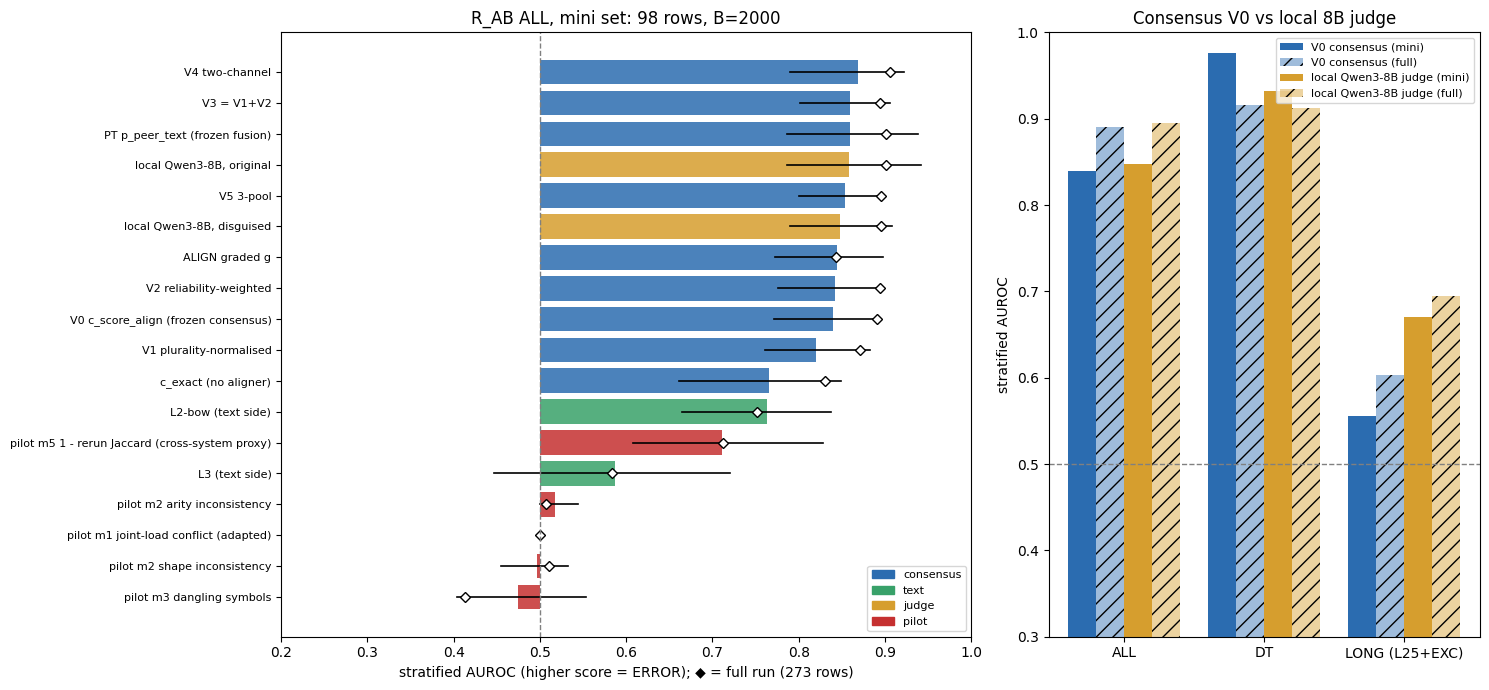

FULL-RUN headline (273 rows, B=2000):
  ALL  : V0 0.890 vs local judge 0.895  (delta -0.005)
  DT   : V0 0.916 vs local judge 0.913  (delta +0.003)
  LONG : V0 0.603 vs local judge 0.695  (76 ERR / 18 COR -> NOT_TESTABLE)
  pilot metrics (ALL): joint_conflict=0.500, arity_incons=0.507, shape_incons=0.510, dangling=0.413, rerun_jacc=0.713

Rename invariance of V0 (full run; share of CORRECT formulas flagged, V0 > 0.5):
  RENAME_SYN    n= 36  after rename: 0.94   before (parent): 0.36
  RENAME_NONCE  n=145  after rename: 1.00   before (parent): 0.26

MINI SET (this run): ALL V0 0.840 vs local judge 0.847; re-derivation exact match: True


In [15]:
fam_color = {"consensus": "#2b6cb0", "text": "#38a169", "judge": "#d69e2e", "pilot": "#c53030"}
def family(m):
    if m.startswith("judge"): return "judge"
    if m.startswith("pilot"): return "pilot"
    if m in ("l2_bow", "l3_z3"): return "text"
    return "consensus"

cA = A["R_AB"]["ALL"]["metrics"]
show = [m for m in METRICS if cA.get(m, {}).get("strat") is not None and cA[m]["n"] >= 50]
show = sorted(show, key=lambda m: cA[m]["strat"])
fig, ax = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.6, 1]})
ypos = np.arange(len(show))
for i, m in enumerate(show):
    v = cA[m]
    lo, hi = v["strat_ci"]
    ax[0].barh(i, v["strat"] - 0.5, left=0.5, color=fam_color[family(m)], alpha=0.85)
    ax[0].plot([lo, hi], [i, i], color="k", lw=1.2)
    full = ref["ALL"]["strat_auroc"].get(m, [None])[0]
    if full is not None:
        ax[0].plot(full, i, marker="D", color="k", ms=5, mfc="white")
ax[0].axvline(0.5, color="grey", ls="--", lw=1)
ax[0].set_yticks(ypos, [LABEL_OF[m] for m in show], fontsize=8)
ax[0].set_xlim(0.2, 1.0)
ax[0].set_xlabel("stratified AUROC (higher score = ERROR); ◆ = full run (273 rows)")
ax[0].set_title(f"R_AB ALL, mini set: {A['R_AB']['ALL']['n_rows']} rows, B={B}")
from matplotlib.patches import Patch
ax[0].legend(handles=[Patch(color=c, label=f) for f, c in fam_color.items()], loc="lower right", fontsize=8)

cells = ["ALL", "DT", "LONG (L25+EXC)"]
w = 0.2
for j, (m, lab) in enumerate(((PRIMARY, "V0 consensus"), ("judge_local_qwen8b_disg", "local Qwen3-8B judge"))):
    mini_v = [A["R_AB"][c]["metrics"][m]["strat"] for c in cells]
    full_v = [ref[c]["strat_auroc"][m][0] for c in cells]
    x = np.arange(len(cells))
    ax[1].bar(x + (2 * j - 1.5) * w, mini_v, w, label=f"{lab} (mini)", color=["#2b6cb0", "#d69e2e"][j])
    ax[1].bar(x + (2 * j - 0.5) * w, full_v, w, label=f"{lab} (full)", color=["#2b6cb0", "#d69e2e"][j], alpha=0.45, hatch="//")
ax[1].axhline(0.5, color="grey", ls="--", lw=1)
ax[1].set_xticks(np.arange(len(cells)), cells)
ax[1].set_ylim(0.3, 1.0)
ax[1].set_ylabel("stratified AUROC")
ax[1].set_title("Consensus V0 vs local 8B judge")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

red = data["metadata"]["full_run_reference"]["rederive_out"]
print("FULL-RUN headline (273 rows, B=2000):")
print(f"  ALL  : V0 {red['ALL']['V0']:.3f} vs local judge {red['ALL']['local_disg']:.3f}  (delta {red['ALL']['delta_V0_minus_local']:+.3f})")
print(f"  DT   : V0 {red['DT']['V0']:.3f} vs local judge {red['DT']['local_disg']:.3f}  (delta {red['DT']['delta_V0_minus_local']:+.3f})")
print(f"  LONG : V0 {red['LONG']['V0']:.3f} vs local judge {red['LONG']['local_disg']:.3f}  (76 ERR / 18 COR -> NOT_TESTABLE)")
print("  pilot metrics (ALL): " + ", ".join(f"{m.replace('pilot_', '')}={red['ALL'][m]:.3f}" for m in
      ("pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_rerun_jacc")))
ren = data["metadata"]["full_run_reference"]["rename_V0"]
print("\nRename invariance of V0 (full run; share of CORRECT formulas flagged, V0 > 0.5):")
for t in ("RENAME_SYN", "RENAME_NONCE"):
    print(f"  {t:13s} n={ren[t]['n']:3d}  after rename: {ren[t]['FA_control']:.2f}   before (parent): {ren[t]['FA_parent_base']:.2f}")
print(f"\nMINI SET (this run): ALL V0 {A['R_AB']['ALL']['metrics'][PRIMARY]['strat']:.3f} vs local judge "
      f"{A['R_AB']['ALL']['metrics']['judge_local_qwen8b_disg']['strat']:.3f}; "
      f"re-derivation exact match: {all(v['V0_absdiff'] < 1e-9 for v in out['comparison_with_pipeline'].values())}")